# Circular UMAP + plot1cell-style visualizations

This tutorial reproduces the full visualization suite of the R
package [**plot1cell**](https://github.com/HaojiaWu/plot1cell)
(Wu 2021) using `omicverse.pl`. Each section corresponds to one
plot1cell function; where an `ov.pl` equivalent already exists
we use it, otherwise we either ship a new function (as in
Section 1 — `ov.pl.plot1cell`) or demonstrate a Python-native
alternative (Section 9 — `upsetplot`).

| plot1cell (R)                   | omicverse.pl |
|---------------------------------|--------------|
| `plot_circlize` + `add_track`   | `plot1cell`  |
| `complex_dotplot_single/multiple` | `dotplot`, `markers_dotplot` |
| `complex_featureplot`           | `embedding` (multi-panel) |
| `complex_vlnplot_single/multiple` | `violin`, `violin_box` |
| `complex_heatmap_unique`        | `marker_heatmap` |
| `plot_cell_fraction`            | `cellproportion` |
| `complex_upset_plot`            | `upsetplot` package |
| `plot_qpcr`                     | `single_group_boxplot`, `bardotplot` |


## Setup

We use the classic **pbmc3k** dataset (2 638 cells, 8 Louvain
clusters) as a small, reproducible demo. Two synthetic metadata
columns (`donor`, `condition`) are added so that functions
requiring a multi-group design (dotplot-split, cell-fraction
bars, UpSet on DEGs) have inputs.


In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import omicverse as ov
ov.plot_set()


/home/users/steorra/miniforge3/envs/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.2rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [2]:
adata = sc.datasets.pbmc3k_processed()
rng = np.random.default_rng(0)
adata.obs['donor'] = pd.Categorical(
    rng.choice(['D1', 'D2', 'D3'], size=adata.n_obs))
adata.obs['condition'] = pd.Categorical(
    rng.choice(['ctrl', 'treat'], size=adata.n_obs))
adata


AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain', 'donor', 'condition'
    var: 'n_cells'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_draw_graph_fr'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

## Section 1 — Circular UMAP (`plot_circlize` + `add_track`)

The headline plot1cell view: clusters arranged as arc sectors
on the unit circle, UMAP scatter inside, one metadata ring per
`tracks=` column.


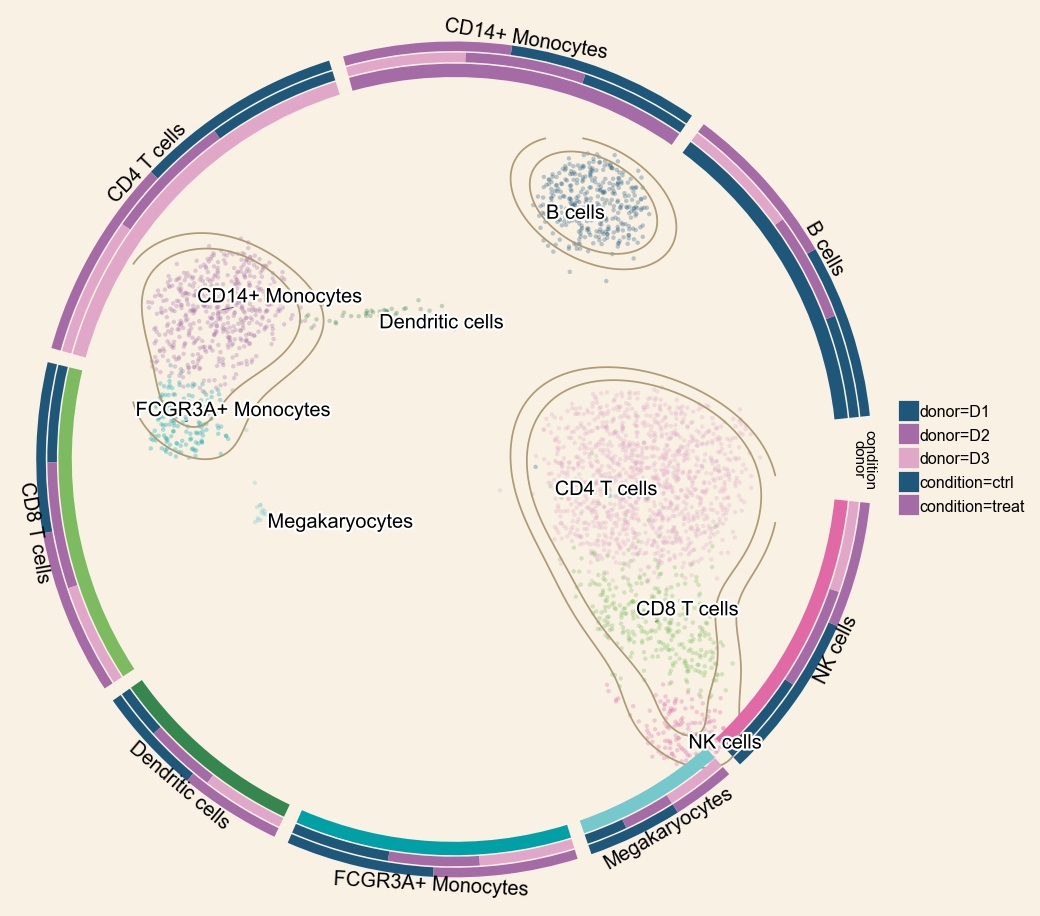

<Axes: >

In [3]:
ov.pl.plot1cell(
    adata, clusters='louvain', basis='X_umap',
    tracks=['donor', 'condition'],
    point_size=4, figsize=(7, 7),
)


## Section 2 — Single-gene dotplot (`complex_dotplot_single`)

Dot size = fraction of cells expressing the gene, colour = mean
expression in expressing cells. ov.pl exposes the scanpy-style
`dotplot` and the omicverse `markers_dotplot`.


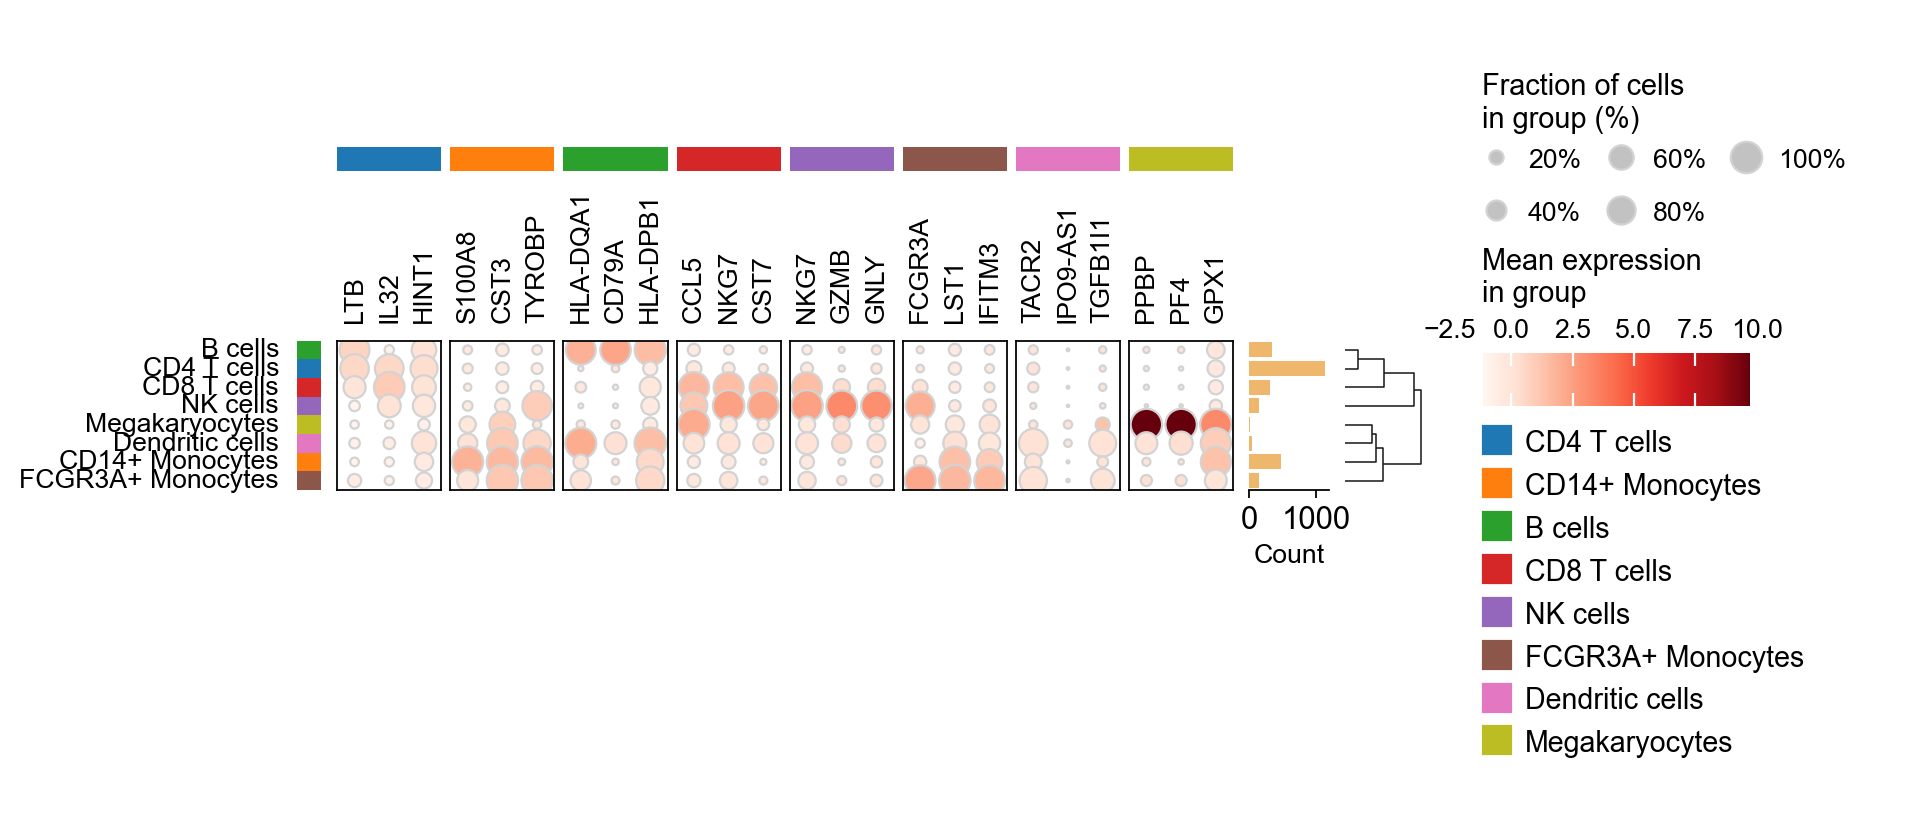

In [4]:
sc.tl.rank_genes_groups(adata, 'louvain', method='wilcoxon',
                        use_raw=False)
markers = ['MS4A1', 'CD3D', 'CD8A', 'NKG7', 'LYZ',
           'FCGR3A', 'FCER1A', 'PPBP']
ov.pl.rank_genes_groups_dotplot(
    adata, n_genes=3, figsize=(8, 4))


## Section 3 — Marker-panel dotplot (`complex_dotplot_multiple`)

Canonical marker panel across clusters, condition-split into
two columns by giving `markers_dotplot` a `groupby` + a `colby`
split.


Auto-detected: 3 genes only in raw data, using raw data automatically


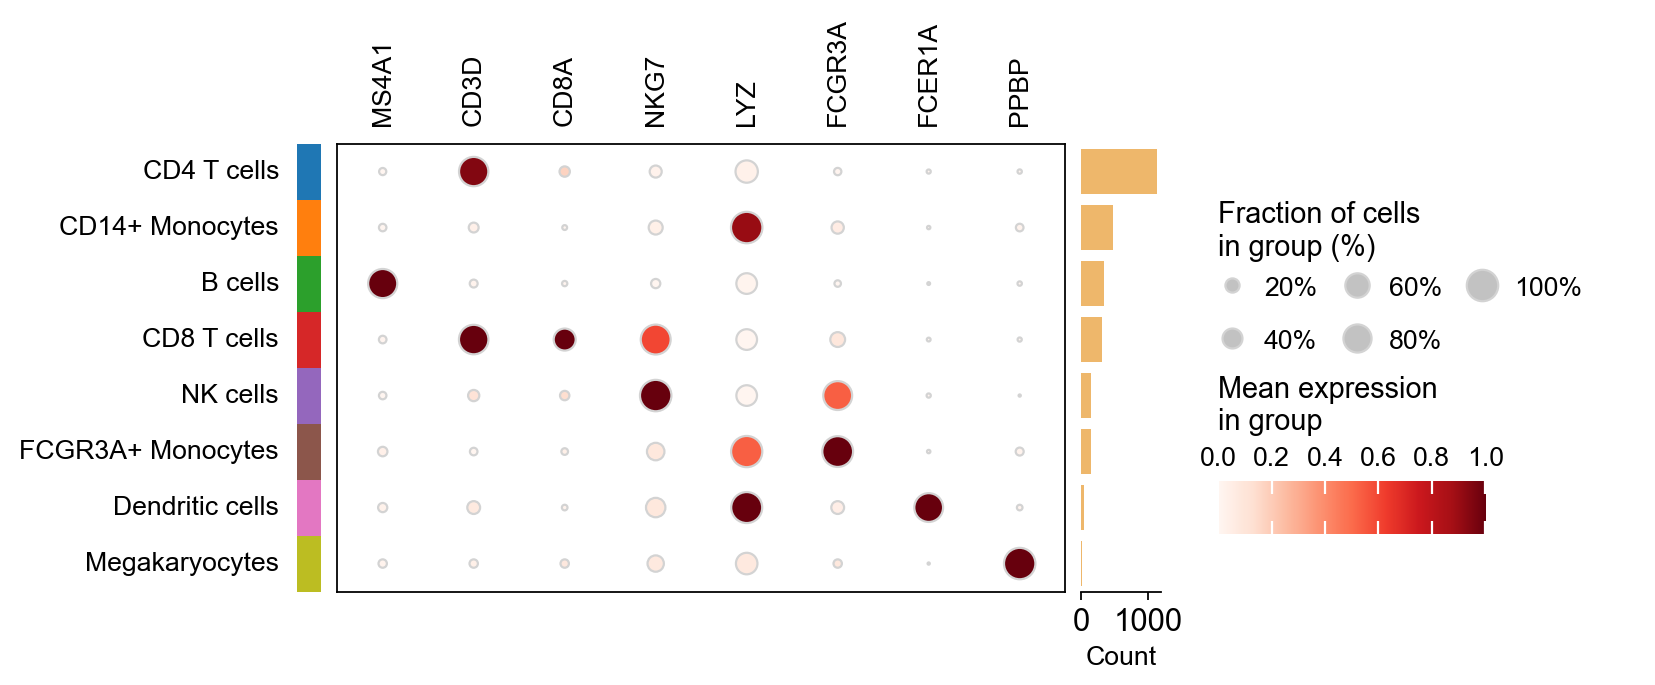

In [5]:
ov.pl.dotplot(
    adata, var_names=markers, groupby='louvain',
    standard_scale='var', figsize=(6.5, 4),
)


## Section 4 — Feature plot grid (`complex_featureplot`)

Gene expression on the UMAP, one subplot per gene. The R
version facets by (gene × group); we build the grid with
matplotlib and reuse `ov.pl.embedding` per cell.


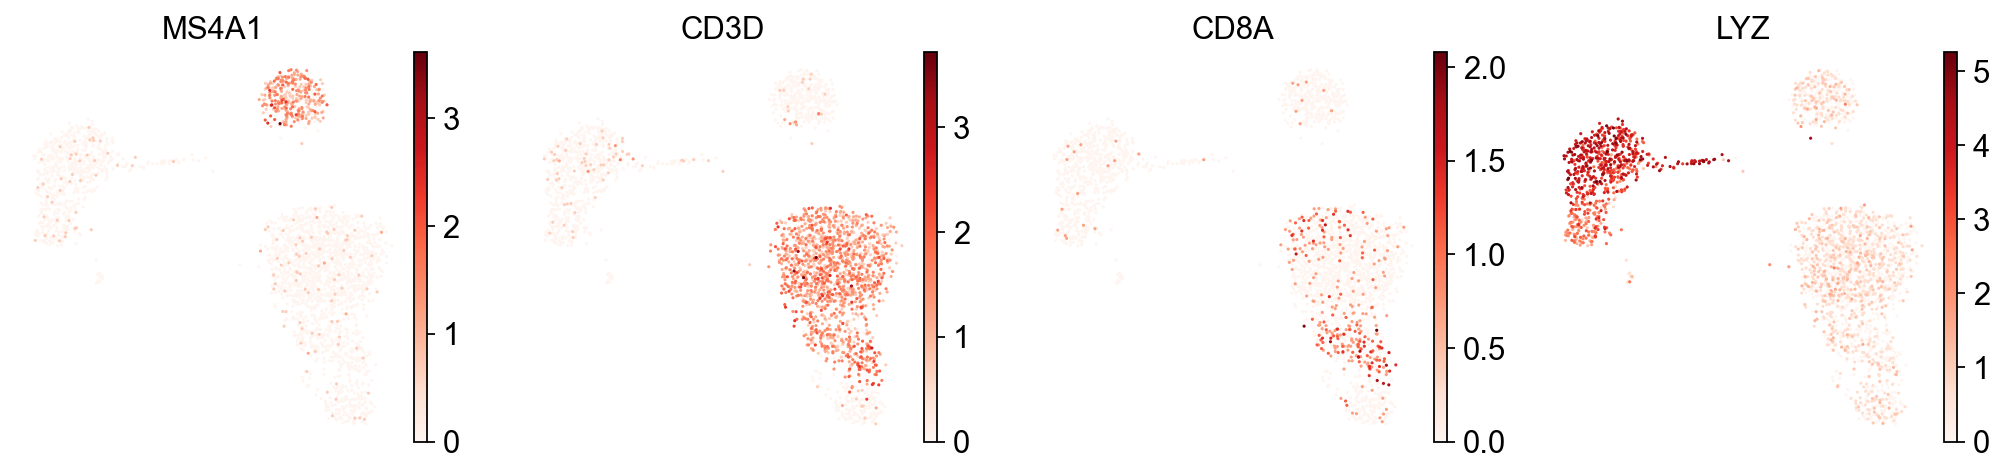

In [6]:
import matplotlib.pyplot as plt
genes = ['MS4A1', 'CD3D', 'CD8A', 'LYZ']
fig, axes = plt.subplots(1, len(genes), figsize=(3.2 * len(genes), 3.2))
for ax, g in zip(axes, genes):
    sc.pl.umap(adata, color=g, ax=ax, show=False, frameon=False,
               cmap='Reds', size=8)
    ax.set_title(g)
fig.tight_layout(); plt.show()


## Section 5 — Single-gene violin (`complex_vlnplot_single`)

Expression of one gene across clusters. `ov.pl.violin` wraps
scanpy's violin with omicverse styling.


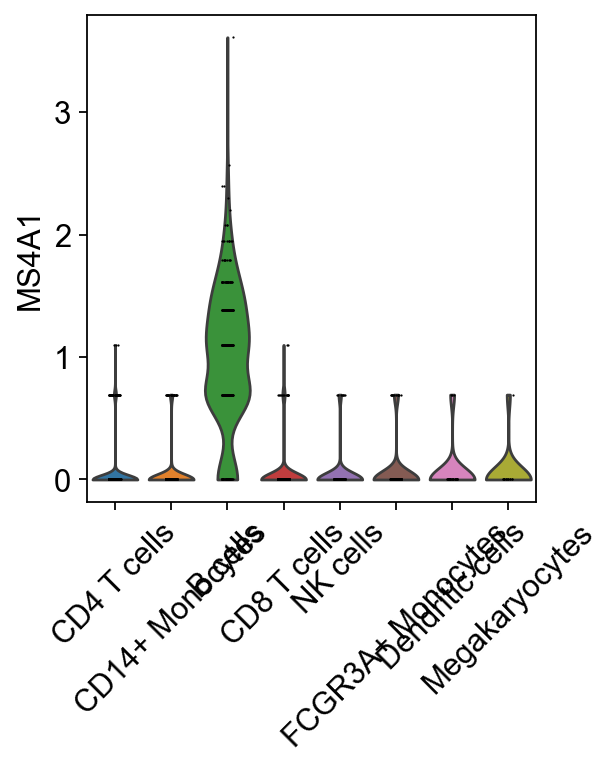

In [7]:
sc.pl.violin(adata, keys='MS4A1', groupby='louvain',
             rotation=45, show=True)


## Section 6 — Multi-gene stacked violin (`complex_vlnplot_multiple`)

Multiple markers stacked as one row per gene, columns = clusters.
scanpy's `stacked_violin` is the direct equivalent.


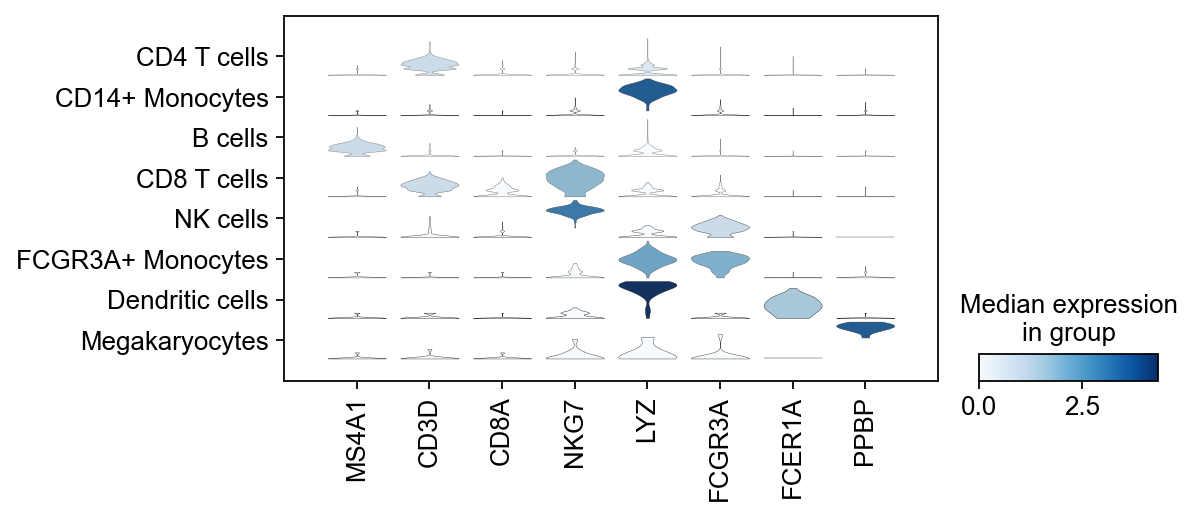

In [8]:
sc.pl.stacked_violin(
    adata, var_names=markers, groupby='louvain',
    swap_axes=False, figsize=(7, 3),
)


## Section 7 — Marker heatmap (`complex_heatmap_unique`)

Top cluster-specific genes as a row-normalised heatmap. plot1cell
does this via ComplexHeatmap; we use `ov.pl.marker_heatmap`.


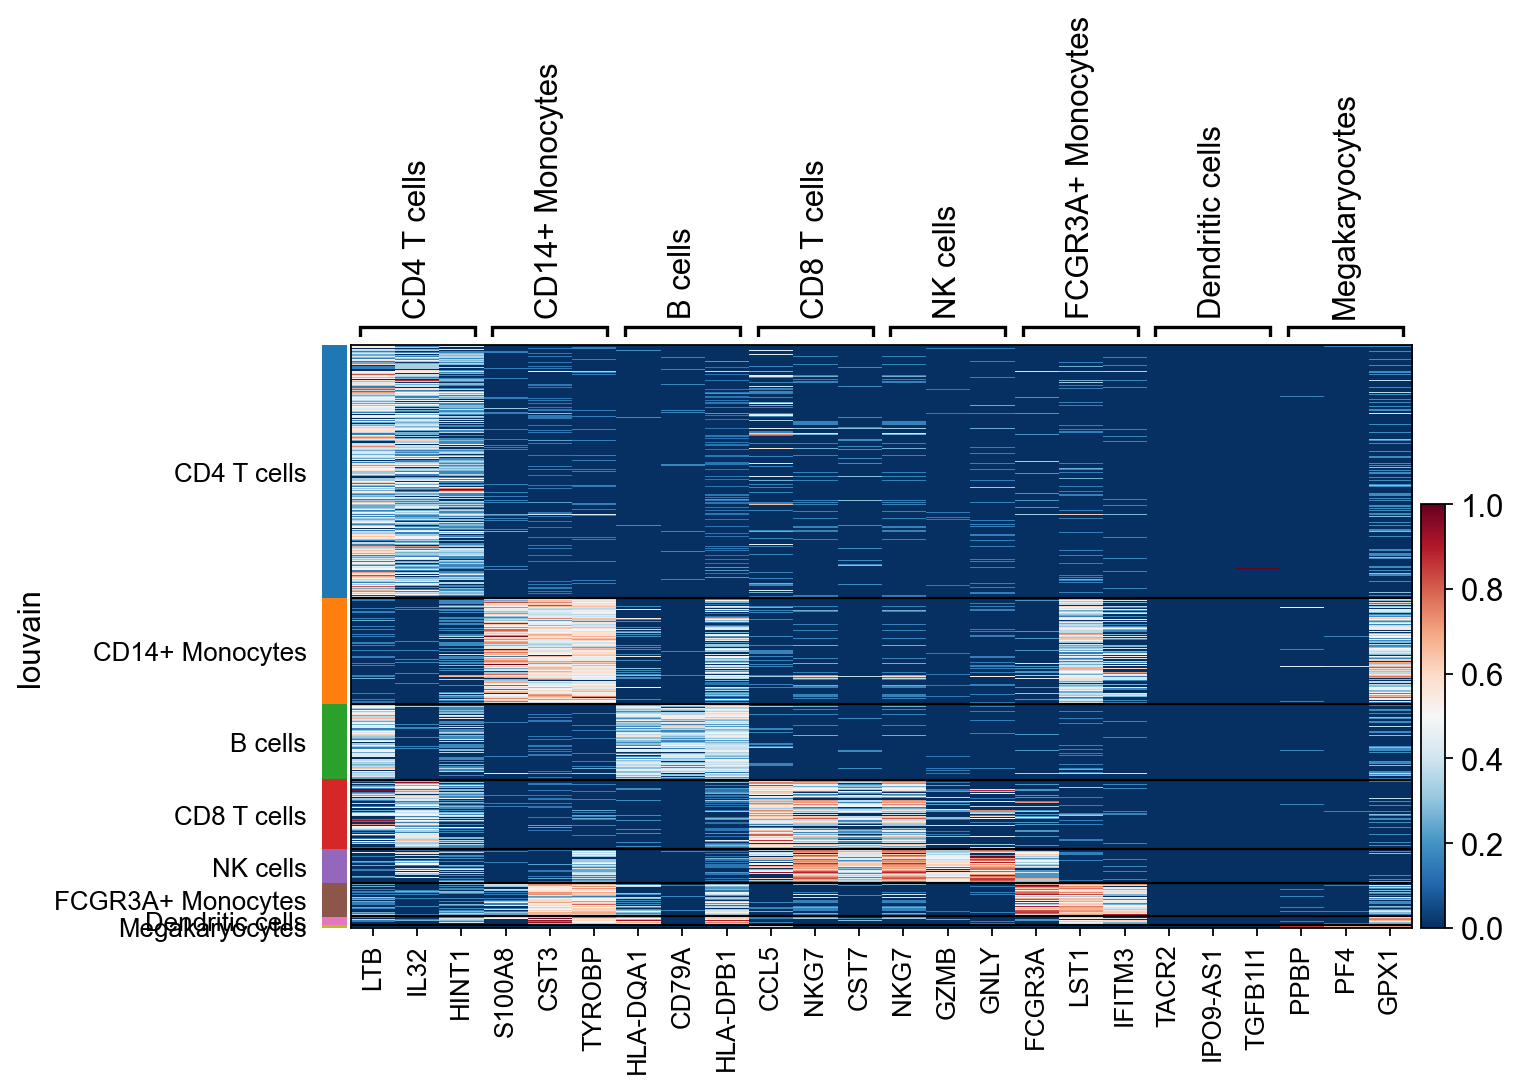

In [9]:
top_markers = {g: list(sc.get.rank_genes_groups_df(adata, group=g).names.head(3))
               for g in adata.obs['louvain'].cat.categories}
sc.pl.heatmap(
    adata, var_names=top_markers, groupby='louvain',
    standard_scale='var', cmap='RdBu_r', figsize=(9, 5),
)


## Section 8 — Cell-fraction across donors (`plot_cell_fraction`)

Per-cluster composition split by donor. `ov.pl.cellproportion`
produces the stacked-bar variant; `cellstackarea` is the
flowing-river alternative.


(<Figure size 320x320 with 1 Axes>,
 <Axes: xlabel='donor', ylabel='Cells per Stage'>)

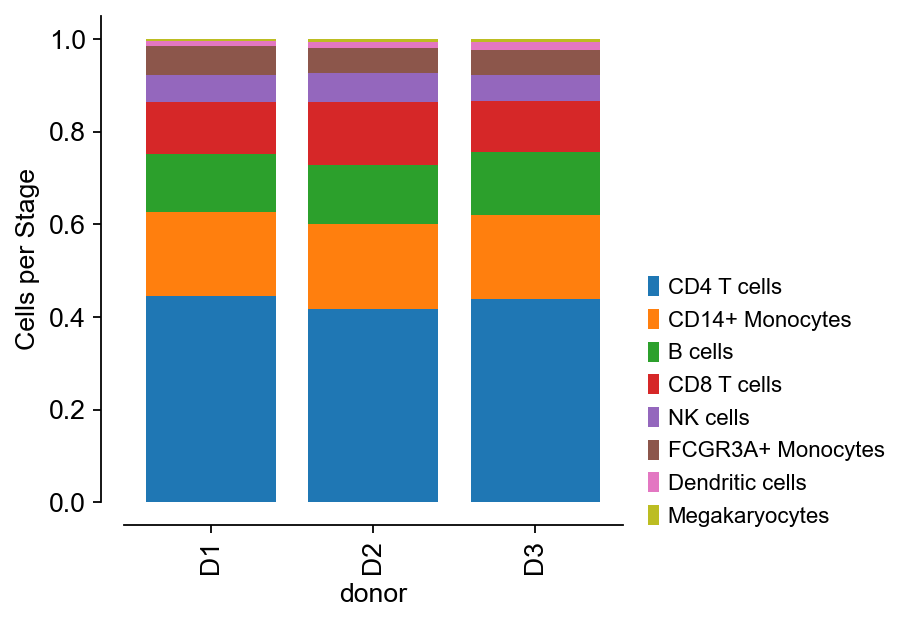

In [10]:
ov.pl.cellproportion(
    adata=adata, celltype_clusters='louvain',
    groupby='donor', legend=True, figsize=(4, 4),
)


## Section 9 — DEG UpSet (`complex_upset_plot`)

Intersection of marker sets across cluster groups. `ov.pl` does
not ship an UpSet; we use the `upsetplot` package directly.


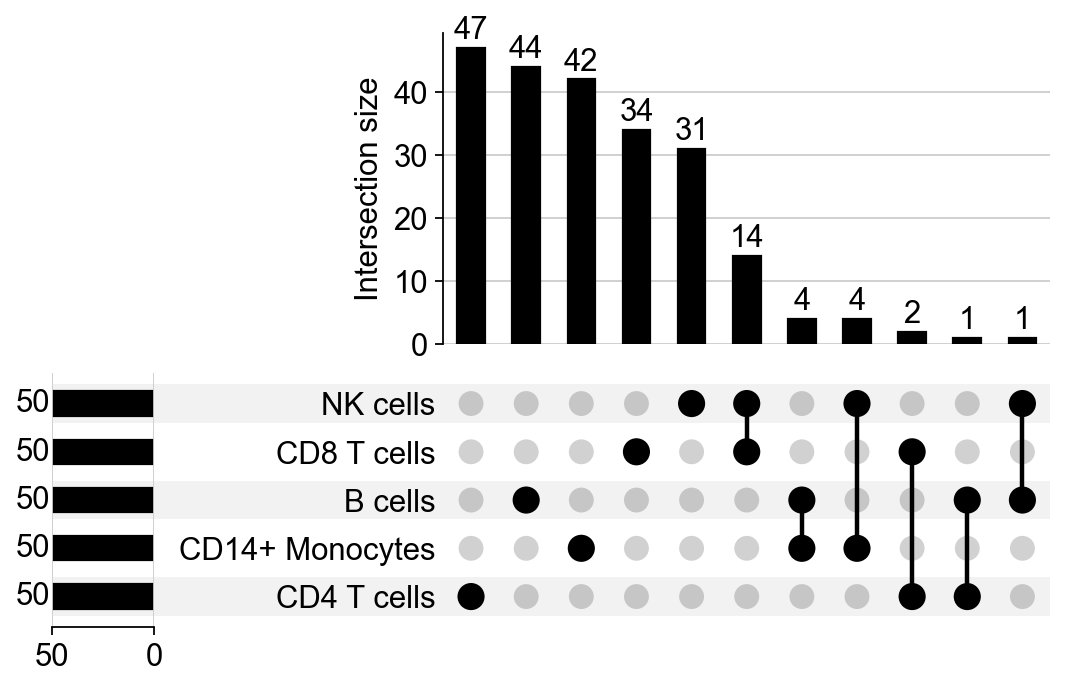

In [11]:
from upsetplot import UpSet, from_contents
import matplotlib.pyplot as plt
res = sc.get.rank_genes_groups_df(adata, group=None)
top = {g: set(res[res.group == g].names.head(50))
       for g in res.group.unique()[:5]}
UpSet(from_contents(top), show_counts=True,
      sort_by='cardinality').plot()
plt.show()


## Section 10 — qPCR-style bars (`plot_qpcr`)

Mean ± SE of one gene across clusters. `ov.pl.single_group_boxplot`
is the closest built-in; for a pure bar/error-bar look we use
matplotlib directly.


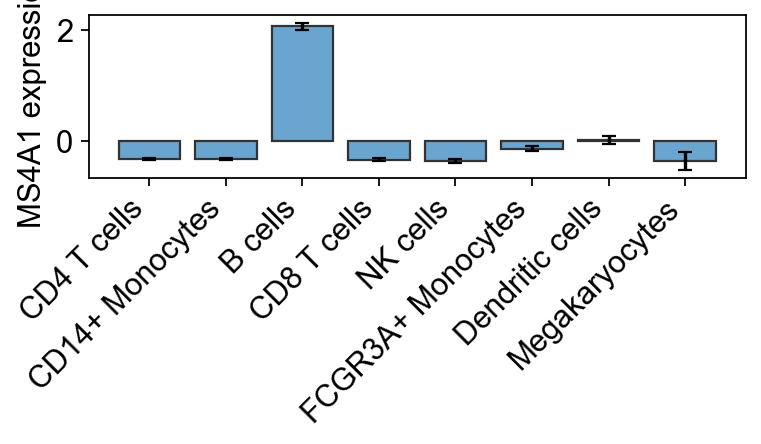

In [12]:
import matplotlib.pyplot as plt
g = 'MS4A1'
df = pd.DataFrame({
    'expr': adata[:, g].X.toarray().ravel()
            if hasattr(adata.X, 'toarray') else adata[:, g].X.ravel(),
    'louvain': adata.obs['louvain'].values,
})
agg = df.groupby('louvain', observed=True)['expr'].agg(['mean', 'sem'])
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(agg.index, agg['mean'], yerr=agg['sem'], capsize=3,
       color='#6AA5CF', edgecolor='#333')
ax.set_ylabel(f'{g} expression'); plt.xticks(rotation=45, ha='right')
fig.tight_layout(); plt.show()


## Summary

Every plot1cell visualization has a direct `ov.pl` (or
Python-native) equivalent. The only new entrypoint introduced
in omicverse is `ov.pl.plot1cell`, a pure-matplotlib port of
`plot_circlize` / `add_track` that works directly on an AnnData
without ever touching R or Seurat.

**Key parameters of `ov.pl.plot1cell`:**

- `clusters` — obs column (required).
- `basis` — obsm key, default `'X_umap'`.
- `tracks` — list of obs columns to show as concentric rings.
- `coord_scale` — how much of the unit circle the scatter fills.
- `contour_levels` — KDE contour level set, or `None` to disable.
- `label_orient` — `'auto'` | `'tangent'` | `'radial'`;
  auto picks tangent for ≤10 clusters and radial otherwise so
  labels never overlap on the outer ring.
